In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(np.float64(-0.5), np.float64(755.5), np.float64(1007.5), np.float64(-0.5))

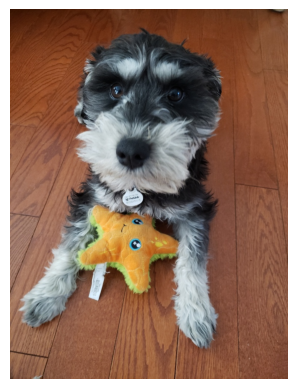

In [ ]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import os
from scipy.fftpack import dct, idct

DEFAULT_WAVELET = 'db4'

def rgb_to_ycbcr(img_rgb):
    return cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2YCrCb).astype(np.float64)


def ycbcr_to_rgb(img_ycbcr):
    img_ycbcr_clipped = np.clip(img_ycbcr, 0, 255)
    return cv2.cvtColor(img_ycbcr_clipped.astype(np.uint8), cv2.COLOR_YCrCb2RGB)


def calculate_snr(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    signal_power = np.mean(original**2)
    noise_power = np.mean((original - reconstructed)**2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

def MSE(actu, pred):
     return np.square(actu.astype(np.float32) - pred.astype(np.float32)).mean()

# --- DWT Implementation ---

def dwt_compress_reconstruct(img_ycbcr, wavelet, level, keep_percentage):
    h, w, c = img_ycbcr.shape
    print(img_ycbcr.shape)
    reconstructed_img = np.zeros_like(img_ycbcr, dtype=np.float64)
    reduction_factor = keep_percentage / 100.0

    for channel in range(c):
        # Decompose
        coeffs_structure = pywt.wavedec2(img_ycbcr[:, :, channel], wavelet, level=level)
        coeffs_thresholded = [None] * len(coeffs_structure) # Initialize list for thresholded coeffs

        # Keep approximation coefficients (LL)
        coeffs_thresholded[0] = coeffs_structure[0]

        # Threshold each detail component (LH, HL, HH) at each level individually
        for i in range(1, len(coeffs_structure)): # Iterate through levels (starting from details)
            thresholded_details_for_level = []
            # coeffs_structure[i] is a tuple (LH, HL, HH)
            for detail_array in coeffs_structure[i]:
                if detail_array.size == 0: # Handle potential empty arrays
                    thresholded_details_for_level.append(detail_array)
                    continue

                abs_coeffs = np.abs(detail_array.flatten())
                coeffs_to_keep = int(round(abs_coeffs.size * reduction_factor))

                thresholded_array = np.copy(detail_array) # Work on a copy

                if 0 < coeffs_to_keep < abs_coeffs.size:
                    # Sort absolute values of *this detail component* in descending order
                    sorted_abs_coeffs = np.sort(abs_coeffs)[::-1]
                    # Find the threshold value (the k-th largest absolute coefficient)
                    threshold = sorted_abs_coeffs[coeffs_to_keep - 1] # -1 because index is 0-based
                    # Apply threshold to this specific detail component
                    thresholded_array[np.abs(detail_array) < threshold] = 0
                elif coeffs_to_keep == 0:
                    # Set all coefficients to zero if keeping 0%
                    thresholded_array[:] = 0
                # If coeffs_to_keep >= abs_coeffs.size, keep all coefficients (no thresholding)

                thresholded_details_for_level.append(thresholded_array)

            # Store the tuple of thresholded details for this level
            coeffs_thresholded[i] = tuple(thresholded_details_for_level)

        # Reconstruct
        reconstructed_channel = pywt.waverec2(coeffs_thresholded, wavelet)
        # Ensure reconstructed size matches original
        rh, rw = reconstructed_channel.shape
        reconstructed_img[:min(rh, h), :min(rw, w), channel] = reconstructed_channel[:min(rh, h), :min(rw, w)]

    return reconstructed_img

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'
# load image
original_img_bgr = cv2.imread(work_path + 'Data/Dog.jpg')
original_img_rgb = cv2.cvtColor(original_img_bgr, cv2.COLOR_BGR2RGB)
original_img_ycbcr = rgb_to_ycbcr(original_img_rgb)

# plot image
import matplotlib.pyplot as plt
plt.imshow(original_img_rgb, cmap='gray')
plt.axis('off')


  Reduction: 95.0% (Keep: 5.0%)
(1008, 756, 3)
    SNR: 28.81 dB
    MSE: 16.58


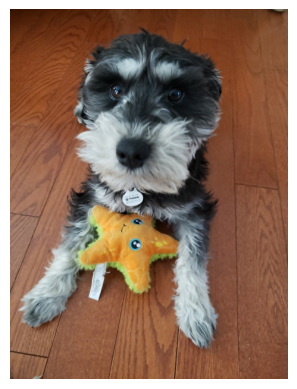

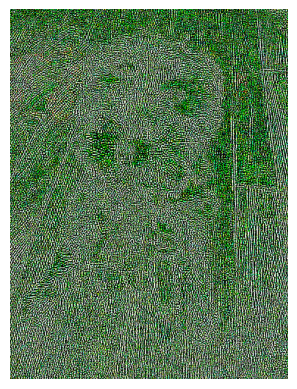

In [ ]:
# --- DWT Processing ---
level = 2
p_reduce = 95

p_keep = 100.0 - p_reduce
print(f"  Reduction: {p_reduce:.1f}% (Keep: {p_keep:.1f}%)")

rec_ycbcr = dwt_compress_reconstruct(original_img_ycbcr.copy(), DEFAULT_WAVELET, level, p_keep)
rec_rgb = ycbcr_to_rgb(rec_ycbcr)

error_img_rgb = original_img_rgb - rec_rgb

# --- Plot Results ---

plt.figure()
plt.imshow(rec_rgb)
plt.axis('off')

plt.figure()
plt.imshow(error_img_rgb)
plt.axis('off')


snr = calculate_snr(original_img_rgb, rec_rgb)
print(f"    SNR: {snr:.2f} dB")
MSE_value = MSE(original_img_rgb, rec_rgb)
print(f"    MSE: {MSE_value:.2f}")